In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Data/crypto_sentiment_prediction_dataset.csv')
df.head()

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,2025-06-04 20:36:49,Algorand,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,2025-06-04 20:48:25,Cosmos,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,2025-06-04 21:28:54,Cosmos,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2025-06-04 21:57:48,Ethereum,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,2025-06-04 22:06:40,Solana,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8


In [4]:
df.columns

Index(['timestamp', 'cryptocurrency', 'current_price_usd',
       'price_change_24h_percent', 'trading_volume_24h', 'market_cap_usd',
       'social_sentiment_score', 'news_sentiment_score', 'news_impact_score',
       'social_mentions_count', 'fear_greed_index', 'volatility_index',
       'rsi_technical_indicator', 'prediction_confidence'],
      dtype='object')

In [5]:
df.duplicated().sum()

0

In [6]:
print("The Number of Rows    :-",df.shape[0])
print("The Number of Columns :-",df.shape[1])

The Number of Rows    :- 2063
The Number of Columns :- 14


In [7]:
df.isnull().sum()

timestamp                   0
cryptocurrency              0
current_price_usd           0
price_change_24h_percent    0
trading_volume_24h          0
market_cap_usd              0
social_sentiment_score      0
news_sentiment_score        0
news_impact_score           0
social_mentions_count       0
fear_greed_index            0
volatility_index            0
rsi_technical_indicator     0
prediction_confidence       0
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2063 entries, 0 to 2062
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 2063 non-null   object 
 1   cryptocurrency            2063 non-null   object 
 2   current_price_usd         2063 non-null   float64
 3   price_change_24h_percent  2063 non-null   float64
 4   trading_volume_24h        2063 non-null   float64
 5   market_cap_usd            2063 non-null   float64
 6   social_sentiment_score    2063 non-null   float64
 7   news_sentiment_score      2063 non-null   float64
 8   news_impact_score         2063 non-null   float64
 9   social_mentions_count     2063 non-null   int64  
 10  fear_greed_index          2063 non-null   float64
 11  volatility_index          2063 non-null   float64
 12  rsi_technical_indicator   2063 non-null   float64
 13  prediction_confidence     2063 non-null   float64
dtypes: float

### Interpretation
- This Datasets Contain 2063 Observation(Rows) and 12 attributes(Columns)
- This Datasets Does not Contain any `Missing Values and Duplicated Values`
- We have 12 Numerical Columns and 2 Categorical Columns

In [9]:
df.describe().T[['mean','50%']]

,mean,50%
current_price_usd,4.260361e+03,1.334420e+01
price_change_24h_percent,-1.804169e-02,2.000000e-02
trading_volume_24h,5.889564e+06,3.633502e+06
market_cap_usd,4.568510e+13,1.255924e+11
social_sentiment_score,1.115802e-02,1.200000e-02
news_sentiment_score,2.375182e-03,7.000000e-03
news_impact_score,3.688366e+00,3.670000e+00
social_mentions_count,1.218317e+03,4.090000e+02
fear_greed_index,5.049491e+01,5.060000e+01
volatility_index,7.643694e+01,7.900000e+01


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a method used to understand patterns present in the data.

There are generally three types of EDA:

1. **Univariate Analysis :** When we analyze a single column at a time, it is called univariate analysis.

2. **Bivariate Analysis :** When we analyze two columns together, it is called bivariate analysis.

3. **Multivariate Analysis :** When we analyze more than two columns at the same time, it is called multivariate analysis.

### Univariate Analysis

In [10]:
df_cat = df.select_dtypes('object')
df_cat

,timestamp,cryptocurrency
0,2025-06-04 20:36:49,Algorand
1,2025-06-04 20:48:25,Cosmos
2,2025-06-04 21:28:54,Cosmos
3,2025-06-04 21:57:48,Ethereum
4,2025-06-04 22:06:40,Solana
...,...,...
2058,2025-07-04 17:16:03,Cardano
2059,2025-07-04 17:25:39,Ethereum
2060,2025-07-04 17:43:50,Polkadot
2061,2025-07-04 19:31:59,Polygon


### Univariate Analysis on Categorical Columns

#### cryptocurrency: Name of the cryptocurrency (string, includes 10 major tokens like Bitcoin, Ethereum, etc.).

<Axes: xlabel='cryptocurrency'>

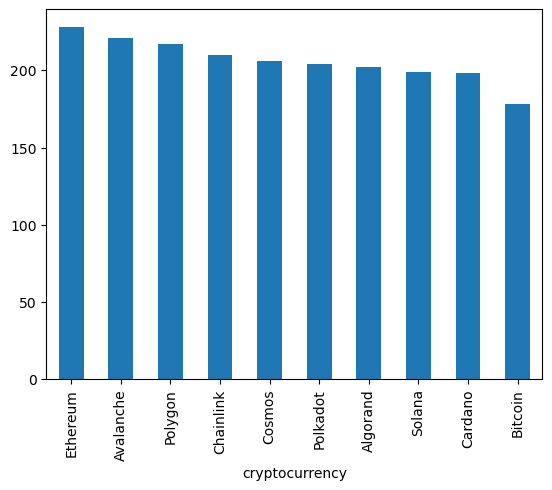

In [11]:
df_cat['cryptocurrency'].value_counts().plot(kind='bar')

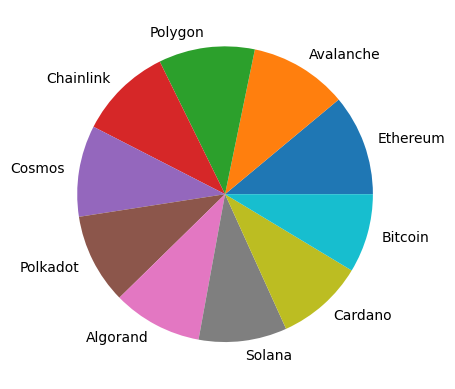

In [12]:
value = df_cat['cryptocurrency'].value_counts()
l= df_cat['cryptocurrency'].value_counts().index

plt.pie(value,labels=l)
plt.show()

In [13]:
I = df_cat['cryptocurrency'].value_counts().index
V = df_cat['cryptocurrency'].value_counts().values

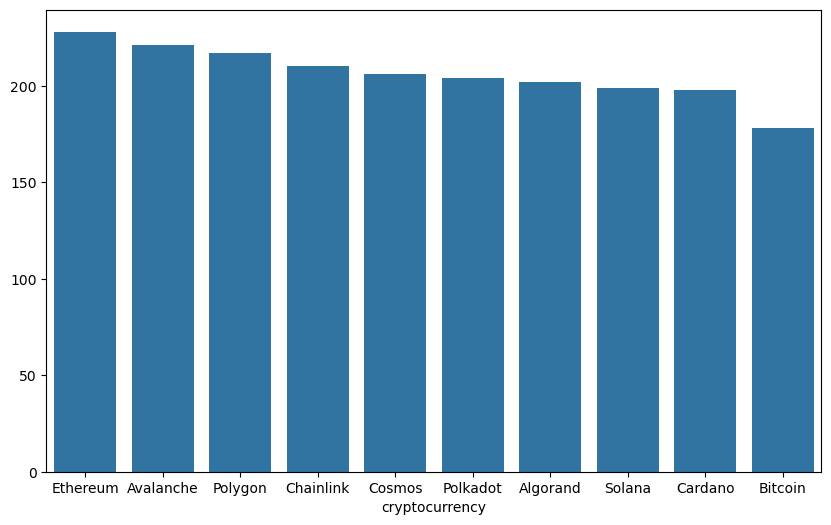

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x=I,y=V)
plt.show()

In [15]:
df_cat['cryptocurrency'].value_counts()

cryptocurrency
Ethereum     228
Avalanche    221
Polygon      217
Chainlink    210
Cosmos       206
Polkadot     204
Algorand     202
Solana       199
Cardano      198
Bitcoin      178
Name: count, dtype: int64

In [16]:
df.describe()

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
count,2063.000000,2063.000000,2.063000e+03,2.063000e+03,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000,2063.000000
mean,4260.360520,-0.018042,5.889564e+06,4.568510e+13,0.011158,0.002375,3.688366,1218.317014,50.494910,76.436937,50.501503,77.123413
std,12603.767442,8.000837,7.451165e+06,1.581473e+14,0.303325,0.308788,1.712072,2501.245623,13.367164,21.245765,15.116517,6.651359
min,0.298700,-25.560000,2.060664e+05,5.022090e+07,-1.000000,-1.000000,0.070000,2.000000,0.000000,21.400000,1.400000,55.900000
25%,1.208650,-5.755000,1.835157e+06,1.113379e+10,-0.197500,-0.202000,2.390000,143.500000,41.400000,60.700000,40.250000,72.650000
50%,13.344200,0.020000,3.633502e+06,1.255924e+11,0.012000,0.007000,3.670000,409.000000,50.600000,79.000000,50.500000,76.700000
75%,84.970000,5.755000,7.111602e+06,7.634962e+11,0.215000,0.211500,4.970000,1178.000000,59.400000,100.000000,60.550000,81.100000
max,51610.923200,27.080000,1.402925e+08,1.009556e+15,1.000000,1.000000,9.530000,35578.000000,100.000000,100.000000,97.100000,100.000000


#### Numberical Columns

In [17]:
df_num = df.select_dtypes('number')
df_num

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
0,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1
1,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7
2,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4
3,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7
4,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8
...,...,...,...,...,...,...,...,...,...,...,...,...
2058,0.4492,-4.66,6345791.01,8.185563e+09,0.327,0.009,2.54,1695,56.5,77.3,51.9,72.4
2059,3077.3009,0.33,590629.81,2.546980e+13,-0.277,-0.143,2.31,1093,40.1,30.4,40.5,79.2
2060,8.1297,11.93,24276229.78,1.224982e+11,0.216,0.001,3.07,401,51.7,93.3,41.6,71.0
2061,1.1212,-7.76,2126227.67,2.240884e+10,0.144,0.160,2.32,202,66.3,76.2,37.6,74.8


In [18]:
df_num.corr()

,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence
current_price_usd,1.000000,0.034770,0.056948,0.855284,-0.025443,-0.065416,-0.019294,0.003760,-0.061391,0.026035,0.033644,-0.025099
price_change_24h_percent,0.034770,1.000000,-0.002488,0.041433,0.010624,0.014640,-0.006943,-0.028388,-0.015151,0.016013,0.024312,0.007128
trading_volume_24h,0.056948,-0.002488,1.000000,0.018735,0.013793,-0.013934,0.003955,-0.021104,0.011471,0.045330,0.011159,0.010919
market_cap_usd,0.855284,0.041433,0.018735,1.000000,-0.030238,-0.067501,-0.008240,0.005734,-0.057291,0.029134,0.037524,-0.024166
social_sentiment_score,-0.025443,0.010624,0.013793,-0.030238,1.000000,0.580926,-0.058285,0.008296,0.659946,0.011029,-0.010687,0.002461
news_sentiment_score,-0.065416,0.014640,-0.013934,-0.067501,0.580926,1.000000,-0.030319,0.002093,0.381134,0.008984,0.016143,-0.025268
news_impact_score,-0.019294,-0.006943,0.003955,-0.008240,-0.058285,-0.030319,1.000000,-0.010954,-0.045004,-0.036073,-0.037439,0.297177
social_mentions_count,0.003760,-0.028388,-0.021104,0.005734,0.008296,0.002093,-0.010954,1.000000,0.019126,0.023292,-0.019042,0.001363
fear_greed_index,-0.061391,-0.015151,0.011471,-0.057291,0.659946,0.381134,-0.045004,0.019126,1.000000,-0.002925,-0.018361,0.006714
volatility_index,0.026035,0.016013,0.045330,0.029134,0.011029,0.008984,-0.036073,0.023292,-0.002925,1.000000,-0.008731,-0.004148


In [19]:
def correlation(x,y):
    X_variable = df_num[x]
    Y_variable = df_num[y]

    X_bar = X_variable.mean()
    Y_bar = Y_variable.mean()

    
    Numerator = []

    d_x = []
    d_y = []

    for i in range(len(X_variable)):
        n_value = (X_variable[i] - X_bar) * (Y_variable[i] - Y_bar)
        Numerator.append(n_value)

        d_x.append((X_variable[i] - X_bar) ** 2)
        d_y.append((Y_variable[i] - Y_bar) ** 2)

    denometer = sum(d_x) * sum(d_y)

    return sum(Numerator)/(denometer ** 0.5)

correlation('current_price_usd','market_cap_usd')

0.855284211200083

<Axes: xlabel='social_sentiment_score', ylabel='fear_greed_index'>

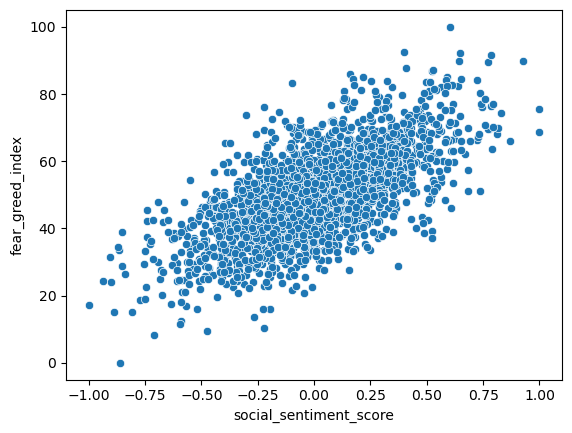

In [20]:
sns.scatterplot(x=df['social_sentiment_score'] ,y=df['fear_greed_index'])

<Axes: xlabel='log_price', ylabel='log_market_cap'>

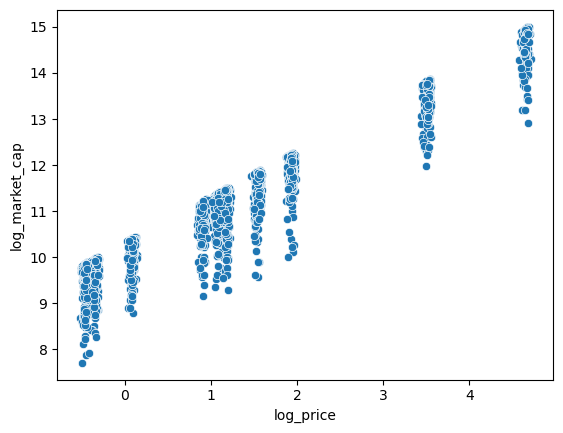

In [21]:
df['log_price'] = np.log10(df['current_price_usd'])
df['log_market_cap'] = np.log10(df['market_cap_usd'])

sns.scatterplot(x=df['log_price'], y=df['log_market_cap'])

<Axes: xlabel='cryptocurrency', ylabel='current_price_usd'>

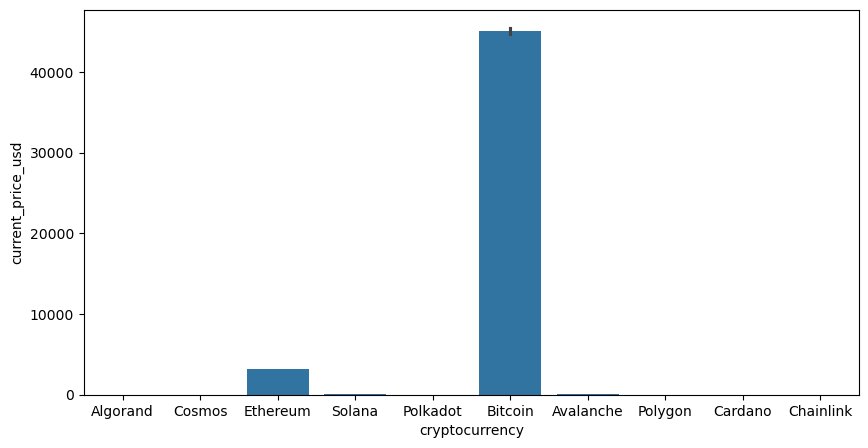

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(x=df['cryptocurrency'],y=df['current_price_usd'])

Extreme Fear (< 25): Panic and selling pressure

Fear (25–49): Cautious or uncertain behavior

Greed (50–74): Optimism and increasing buy pressure

Extreme Greed (≥ 75): Overconfidence and possible overheating

In [31]:
def categorize_fgi(value):
    if value < 25:
        return "Extreme Fear"
    elif (value>=25) and (value<=49):
        return "Fear"
    elif (value>=50) and (value<=74):
        return "Greed"
    else:
        return "Extreme Greed"

df['fear_greed_index'].apply(categorize_fgi).value_counts()

fear_greed_index
Greed            1002
Fear              889
Extreme Greed     119
Extreme Fear       53
Name: count, dtype: int64

In [33]:
df['fgi_category'] = df['fear_greed_index'].apply(categorize_fgi)

In [34]:
df

,timestamp,cryptocurrency,current_price_usd,price_change_24h_percent,trading_volume_24h,market_cap_usd,social_sentiment_score,news_sentiment_score,news_impact_score,social_mentions_count,fear_greed_index,volatility_index,rsi_technical_indicator,prediction_confidence,log_price,log_market_cap,fgi_category
0,2025-06-04 20:36:49,Algorand,0.3427,-5.35,1716266.10,1.762124e+09,0.367,0.374,1.87,13,53.2,95.1,37.2,78.1,-0.465086,9.246036,Greed
1,2025-06-04 20:48:25,Cosmos,12.0420,5.14,10520739.91,2.099178e+11,-0.278,-0.107,1.01,600,43.5,76.7,65.0,66.7,1.080699,11.322049,Fear
2,2025-06-04 21:28:54,Cosmos,11.7675,-6.12,642191.11,1.755367e+11,-0.255,0.211,5.69,279,49.1,60.4,32.3,77.4,1.070684,11.244368,Extreme Greed
3,2025-06-04 21:57:48,Ethereum,2861.2829,-11.54,5356227.76,4.786419e+13,-0.531,-0.081,5.11,3504,37.0,100.0,63.0,81.7,3.456561,13.680011,Fear
4,2025-06-04 22:06:40,Solana,95.3583,5.79,735971.56,2.667611e+11,0.369,0.248,1.82,3236,61.7,67.5,55.4,81.8,1.979359,11.426122,Greed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2058,2025-07-04 17:16:03,Cardano,0.4492,-4.66,6345791.01,8.185563e+09,0.327,0.009,2.54,1695,56.5,77.3,51.9,72.4,-0.347560,9.913049,Greed
2059,2025-07-04 17:25:39,Ethereum,3077.3009,0.33,590629.81,2.546980e+13,-0.277,-0.143,2.31,1093,40.1,30.4,40.5,79.2,3.488170,13.406026,Fear
2060,2025-07-04 17:43:50,Polkadot,8.1297,11.93,24276229.78,1.224982e+11,0.216,0.001,3.07,401,51.7,93.3,41.6,71.0,0.910075,11.088130,Greed
2061,2025-07-04 19:31:59,Polygon,1.1212,-7.76,2126227.67,2.240884e+10,0.144,0.160,2.32,202,66.3,76.2,37.6,74.8,0.049683,10.350419,Greed


- x=fgi_category y=price_change_24h_percent
- x=fgi_category y=volatility_index
- x=fgi_category y=trading_volume_24h

<Axes: xlabel='fgi_category', ylabel='trading_volume_24h'>

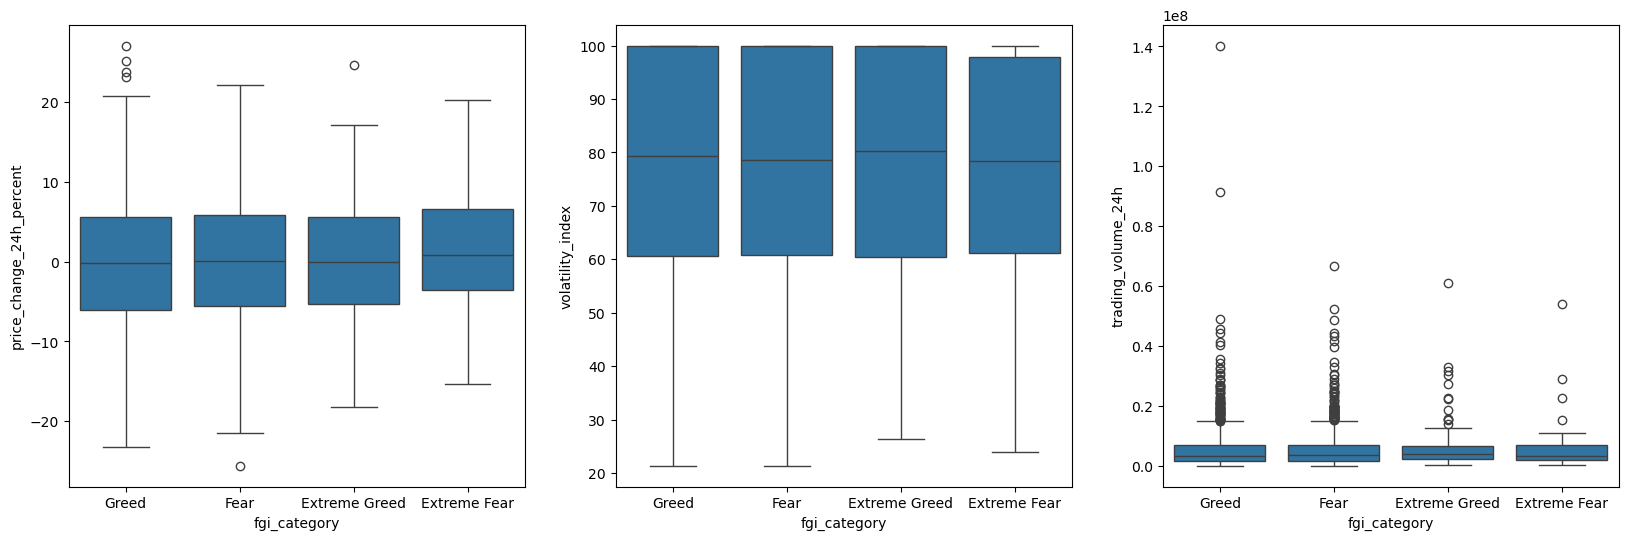

In [53]:
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
sns.boxplot(x='fgi_category',y='price_change_24h_percent',data=df)

plt.subplot(1,3,2)
sns.boxplot(x='fgi_category',y='volatility_index',data=df)

plt.subplot(1,3,3)
sns.boxplot(x='fgi_category',y='trading_volume_24h',data=df)

In [59]:
df[df['fgi_category'] == 'Extreme Greed']['volatility_index'].describe()

count    119.000000
mean      76.803361
std       21.211953
min       26.300000
25%       60.450000
50%       80.200000
75%      100.000000
max      100.000000
Name: volatility_index, dtype: float64